# Energy relaxation time $T_1$

In [1]:
from pathlib import Path

import numpy as np

from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal09_energy_relaxation import EnergyRelaxation

## Run parameters

In [11]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]
DELAYS = np.arange(start=0.1, stop=300, step=0.5) * 1e-6
REPETITIONS = 10

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True

## Hardware and experiment

In [4]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = EnergyRelaxation(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Measurement

In [5]:
dataset = experiment.run_measurement(
    delays=DELAYS,
    repetitions=REPETITIONS,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 13kB
Dimensions:           (acq_index_S21_q0: 400)
Coordinates:
    delay_q0          (acq_index_S21_q0) float64 3kB 1e-07 6e-07 ... 0.0001996
  * acq_index_S21_q0  (acq_index_S21_q0) int64 3kB 0 1 2 3 4 ... 396 397 398 399
Data variables:
    S21_q0            (acq_index_S21_q0) complex128 6kB (-3.16739797592163e-0...
Attributes:
    tuid:     20260812-125825-575-00644d

## Optional: Simulated data

In [12]:
dataset = experiment.simulated_data(
    delays=DELAYS,
    repetitions=REPETITIONS,
    t1=100e-6,
    noise=0.002,
    seed=42,
)

## Analysis

In [13]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(f"{qubit}: T1 = {result.t1 / 1e-6:.3f} us")
    else:
        print(f"{qubit}: T1 fit failed")

q0: T1 = 99.830 us


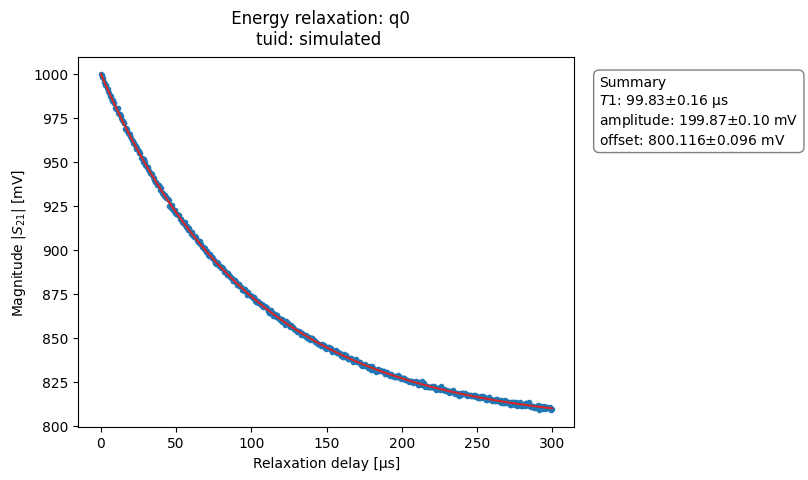

In [14]:
if PLOT_RESULTS:
    experiment.plot()